In [8]:
# ============================================================
# CELL 1 — INSTALL REQUIRED PACKAGES
# ============================================================

!pip -q install ucimlrepo openpyxl seaborn statsmodels

print("All required packages installed.")

All required packages installed.


In [9]:
# ============================================================
# CELL 2 — IMPORTS AND EXPERIMENT CONFIGURATION
# ============================================================

import os
import sys
import time
import json
import random
import platform
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from itertools import combinations

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix
)

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    rankdata
)

from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

# ------------------------------------------------------------
# CROSS-VALIDATION SETTINGS
# ------------------------------------------------------------

OUTER_FOLDS = 5
N_REPEATS = 3

REPEAT_SEEDS = [42, 43, 44]

INNER_FOLDS = 2

PRIMARY_SCORING = "f1_macro"

# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")

RESULTS_DIR.mkdir(
    exist_ok=True
)

FIGURES_DIR.mkdir(
    exist_ok=True
)

print("=" * 70)
print("DRY BEAN MULTI-CLASS BENCHMARK")
print("=" * 70)

print("\nOuter CV:")
print(f"  {OUTER_FOLDS}-fold")

print("\nRepeats:")
print(f"  {N_REPEATS}")

print("\nTotal outer folds:")
print(f"  {OUTER_FOLDS * N_REPEATS}")

print("\nInner CV:")
print(f"  {INNER_FOLDS}-fold")

print("\nPrimary tuning metric:")
print(f"  {PRIMARY_SCORING}")

print("\nRandom seeds:")
print(f"  {REPEAT_SEEDS}")

DRY BEAN MULTI-CLASS BENCHMARK

Outer CV:
  5-fold

Repeats:
  3

Total outer folds:
  15

Inner CV:
  2-fold

Primary tuning metric:
  f1_macro

Random seeds:
  [42, 43, 44]


In [10]:
# ============================================================
# CELL 3 — DOWNLOAD UCI DRY BEAN DATASET
# ============================================================

from ucimlrepo import fetch_ucirepo

print("Downloading UCI Dry Bean Dataset...")

dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.copy()
y = dry_bean.data.targets.copy()

# Convert target DataFrame to Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# Ensure feature names are strings
X.columns = X.columns.astype(str)

print("\nDataset loaded successfully.")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClasses:")
print(sorted(y.unique()))


Dataset loaded successfully.
X shape: (13611, 16)
y shape: (13611,)

Classes:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [11]:
# ============================================================
# CELL 4 — DATASET AUDIT
# ============================================================

audit_df = pd.DataFrame({
    "Audit Item": [
        "Number of rows",
        "Number of features",
        "Number of classes",
        "Missing feature values",
        "Missing target values",
        "Duplicate feature rows",
        "Duplicate complete rows"
    ],

    "Value": [
        X.shape[0],
        X.shape[1],
        y.nunique(),
        int(X.isna().sum().sum()),
        int(y.isna().sum()),
        int(X.duplicated().sum()),
        int(
            pd.concat(
                [X, y],
                axis=1
            ).duplicated().sum()
        )
    ]
})

display(audit_df)

audit_df.to_csv(
    RESULTS_DIR / "dataset_audit.csv",
    index=False
)

# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = (
    y.value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Proportion": (
        class_counts.values / len(y)
    )
})

class_distribution["Percentage"] = (
    class_distribution["Proportion"] * 100
)

display(class_distribution)

class_distribution.to_csv(
    RESULTS_DIR / "class_distribution.csv",
    index=False
)

,Audit Item,Value
0,Number of rows,13611
1,Number of features,16
2,Number of classes,7
3,Missing feature values,0
4,Missing target values,0
5,Duplicate feature rows,68
6,Duplicate complete rows,68


,Class,Count,Proportion,Percentage
0,BARBUNYA,1322,0.097127,9.712732
1,BOMBAY,522,0.038351,3.835133
2,CALI,1630,0.119756,11.975608
3,DERMASON,3546,0.260525,26.052458
4,HOROZ,1928,0.141650,14.165014
5,SEKER,2027,0.148924,14.892366
6,SIRA,2636,0.193667,19.366689


In [12]:
# ============================================================
# CELL 5 — FEATURE INFORMATION
# ============================================================

feature_information = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Missing Values": X.isna().sum().values,
    "Unique Values": X.nunique().values
})

display(feature_information)

feature_information.to_csv(
    RESULTS_DIR / "feature_information.csv",
    index=False
)

,Feature,Data Type,Missing Values,Unique Values
0,Area,int64,0,12011
1,Perimeter,float64,0,13351
2,MajorAxisLength,float64,0,13543
3,MinorAxisLength,float64,0,13543
4,AspectRatio,float64,0,13543
5,Eccentricity,float64,0,13543
6,ConvexArea,int64,0,12066
7,EquivDiameter,float64,0,12011
8,Extent,float64,0,13535
9,Solidity,float64,0,13522


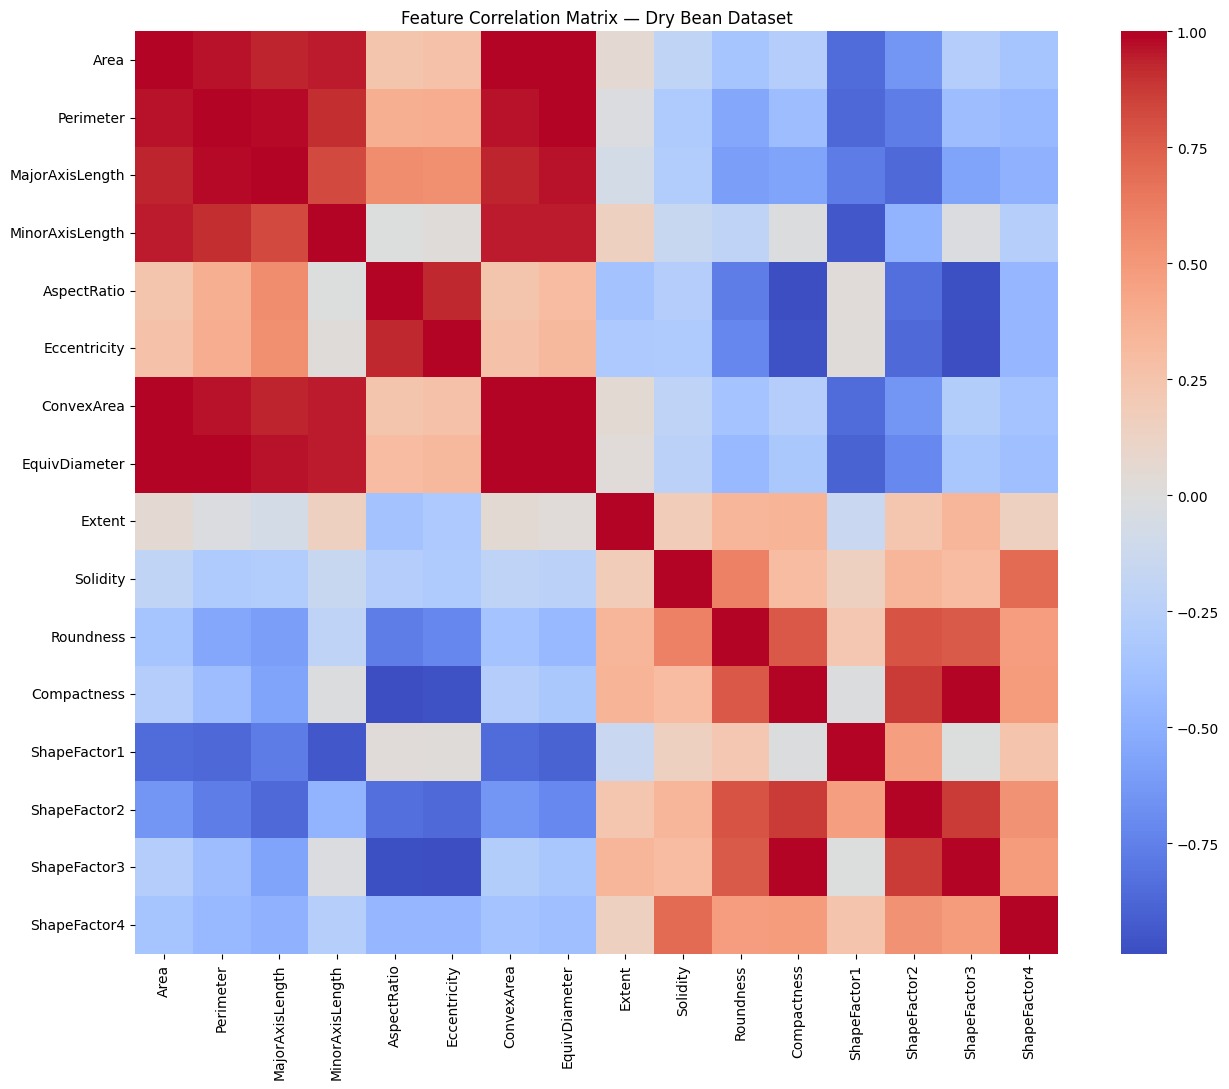

In [13]:
# ============================================================
# CELL 6 — FEATURE CORRELATION MATRIX
# ============================================================

correlation_matrix = X.corr(
    numeric_only=True
)

plt.figure(
    figsize=(14, 11)
)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Feature Correlation Matrix — Dry Bean Dataset"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ============================================================
# CELL 7 — Define reduced-feature ablation
# ============================================================

print("Actual feature names:")
for col in X.columns:
    print(repr(col))

# Domain-informed reduced feature set
REDUCED_DROP = [
    "Perimeter",
    "ConvexArea",
    "EquivalentDiameter",
    "Compactness"
]

# Resolve feature-name variations automatically
feature_aliases = {
    "EquivalentDiameter": [
        "EquivalentDiameter",
        "EquivDiameter",
        "Equivalent Diameter",
        "Equivalent_Diameter"
    ]
}

resolved_drop = []

for feature in REDUCED_DROP:
    if feature in X.columns:
        resolved_drop.append(feature)
    elif feature in feature_aliases:
        found = next(
            (alias for alias in feature_aliases[feature] if alias in X.columns),
            None
        )
        if found:
            resolved_drop.append(found)
        else:
            raise ValueError(
                f"Could not find a column corresponding to '{feature}'."
            )
    else:
        raise ValueError(
            f"Missing expected feature: {feature}"
        )

X_reduced = X.drop(columns=resolved_drop)

print("\nOriginal features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

print("\nDropped features:")
for feature in resolved_drop:
    print("-", feature)

Actual feature names:
'Area'
'Perimeter'
'MajorAxisLength'
'MinorAxisLength'
'AspectRatio'
'Eccentricity'
'ConvexArea'
'EquivDiameter'
'Extent'
'Solidity'
'Roundness'
'Compactness'
'ShapeFactor1'
'ShapeFactor2'
'ShapeFactor3'
'ShapeFactor4'

Original features: 16
Reduced features: 12

Dropped features:
- Perimeter
- ConvexArea
- EquivDiameter
- Compactness


In [15]:
# ============================================================
# CELL 8 — MODEL DEFINITIONS
# ============================================================

def create_models(seed=42):

    models = {

        # ----------------------------------------------------
        # LOGISTIC REGRESSION
        # Linear / probabilistic family
        # ----------------------------------------------------

        "Logistic Regression": {

            "estimator": Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    LogisticRegression(
                        solver="lbfgs",
                        max_iter=500,
                        random_state=seed
                    )
                )
            ]),

            "param_grid": {
                "model__C": [
                    0.1,
                    1.0,
                    10.0
                ]
            }
        },

        # ----------------------------------------------------
        # k-NN
        # Instance-based family
        # ----------------------------------------------------

        "k-NN": {

            "estimator": Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    KNeighborsClassifier()
                )
            ]),

            "param_grid": {
                "model__n_neighbors": [
                    5,
                    11,
                    21
                ]
            }
        },

        # ----------------------------------------------------
        # DECISION TREE
        # Tree family
        # ----------------------------------------------------

        "Decision Tree": {

            "estimator": DecisionTreeClassifier(
                random_state=seed
            ),

            "param_grid": {
                "max_depth": [
                    10,
                    20,
                    None
                ]
            }
        },

        # ----------------------------------------------------
        # RBF SVM
        # Kernel family
        # ----------------------------------------------------

        "RBF SVM": {

            "estimator": Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    SVC(
                        kernel="rbf",
                        gamma="scale",
                        cache_size=4096
                    )
                )
            ]),

            "param_grid": {
                "model__C": [
                    1,
                    10,
                    100
                ]
            }
        }
    }

    return models


models = create_models()

print("Models configured:\n")

for name, configuration in models.items():

    print(name)

    print(
        "Search:",
        configuration["param_grid"]
    )

    print()

Models configured:

Logistic Regression
Search: {'model__C': [0.1, 1.0, 10.0]}

k-NN
Search: {'model__n_neighbors': [5, 11, 21]}

Decision Tree
Search: {'max_depth': [10, 20, None]}

RBF SVM
Search: {'model__C': [1, 10, 100]}



In [16]:
# ============================================================
# CELL 9 — CREATE REPEATED OUTER FOLDS
# ============================================================

outer_splits = []

for repeat_number, seed in enumerate(
    REPEAT_SEEDS,
    start=1
):

    outer_cv = StratifiedKFold(
        n_splits=OUTER_FOLDS,
        shuffle=True,
        random_state=seed
    )

    for fold_number, (
        train_indices,
        test_indices
    ) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):

        outer_splits.append({

            "repeat": repeat_number,

            "seed": seed,

            "fold": fold_number,

            "train_indices": train_indices,

            "test_indices": test_indices
        })

print(
    "Total outer folds:",
    len(outer_splits)
)

assert len(outer_splits) == 15

print(
    "✓ 15 outer folds successfully created."
)

Total outer folds: 15
✓ 15 outer folds successfully created.


In [17]:
# ============================================================
# CELL 10 — OUTER FOLD SANITY CHECK
# ============================================================

for split in outer_splits:

    train_indices = split[
        "train_indices"
    ]

    test_indices = split[
        "test_indices"
    ]

    train_classes = set(
        y.iloc[train_indices]
    )

    test_classes = set(
        y.iloc[test_indices]
    )

    if train_classes != test_classes:

        raise ValueError(
            "A fold does not contain all classes."
        )

print(
    "✓ Every outer training/test fold contains all classes."
)

print(
    "✓ Same predefined folds will be used for every algorithm."
)

✓ Every outer training/test fold contains all classes.
✓ Same predefined folds will be used for every algorithm.


In [18]:
# ============================================================
# CELL 11 — FULL OPTIMIZED REPEATED NESTED CV
# ============================================================

fold_results = []

per_class_results = []

confusion_results = []

experiment_start = time.perf_counter()

total_folds = len(outer_splits)

completed_folds = 0

print("=" * 80)
print("STARTING FULL REPEATED NESTED CROSS-VALIDATION")
print("=" * 80)

print(
    "\nExpected outer folds:",
    total_folds
)

print(
    "Algorithms:",
    len(models)
)

print(
    "Configurations/model:",
    3
)

print(
    "Inner folds:",
    INNER_FOLDS
)

print(
    "\nApproximate model fits:",
    total_folds * len(models) * 3 * INNER_FOLDS
)

print("\n")


# ============================================================
# OUTER LOOP
# ============================================================

for split in outer_splits:

    repeat_number = split["repeat"]

    repeat_seed = split["seed"]

    fold_number = split["fold"]

    train_indices = split[
        "train_indices"
    ]

    test_indices = split[
        "test_indices"
    ]

    X_train = X.iloc[
        train_indices
    ]

    X_test = X.iloc[
        test_indices
    ]

    y_train = y.iloc[
        train_indices
    ]

    y_test = y.iloc[
        test_indices
    ]

    print("\n")
    print("=" * 80)

    print(
        f"REPEAT {repeat_number} | "
        f"FOLD {fold_number}"
    )

    print("=" * 80)


    # ========================================================
    # EACH ALGORITHM
    # ========================================================

    for algorithm_name, configuration in (
        create_models(
            seed=repeat_seed
        ).items()
    ):

        model_start = time.perf_counter()

        print(
            f"\nRunning: {algorithm_name}"
        )

        # ----------------------------------------------------
        # INNER CV
        # ----------------------------------------------------

        inner_cv = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=(
                repeat_seed * 100
                + fold_number
            )
        )

        # ----------------------------------------------------
        # GRID SEARCH
        # ----------------------------------------------------

        search = GridSearchCV(

            estimator=(
                configuration["estimator"]
            ),

            param_grid=(
                configuration["param_grid"]
            ),

            scoring=PRIMARY_SCORING,

            cv=inner_cv,

            n_jobs=-1,

            refit=True,

            return_train_score=False
        )

        # ----------------------------------------------------
        # FIT ONLY ON OUTER TRAINING DATA
        # ----------------------------------------------------

        fit_start = time.perf_counter()

        search.fit(
            X_train,
            y_train
        )

        fit_time = (
            time.perf_counter()
            - fit_start
        )

        # ----------------------------------------------------
        # BEST MODEL FROM INNER CV
        # ----------------------------------------------------

        best_model = (
            search.best_estimator_
        )

        best_params = (
            search.best_params_
        )

        inner_best_score = (
            search.best_score_
        )

        # ----------------------------------------------------
        # OUTER TEST PREDICTION
        # ----------------------------------------------------

        prediction_start = (
            time.perf_counter()
        )

        y_pred = best_model.predict(
            X_test
        )

        prediction_time = (
            time.perf_counter()
            - prediction_start
        )

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_test,
                y_pred
            )
        )

        cohen_kappa = (
            cohen_kappa_score(
                y_test,
                y_pred
            )
        )

        # ----------------------------------------------------
        # CONFUSION MATRIX
        # ----------------------------------------------------

        class_labels = sorted(
            y.unique()
        )

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=class_labels
        )

        # Save confusion matrix cell-by-cell
        for true_index, true_class in enumerate(
            class_labels
        ):

            for predicted_index, predicted_class in enumerate(
                class_labels
            ):

                confusion_results.append({

                    "repeat":
                        repeat_number,

                    "repeat_seed":
                        repeat_seed,

                    "fold":
                        fold_number,

                    "algorithm":
                        algorithm_name,

                    "true_class":
                        true_class,

                    "predicted_class":
                        predicted_class,

                    "count":
                        int(
                            cm[
                                true_index,
                                predicted_index
                            ]
                        )
                })

        # ----------------------------------------------------
        # PER-CLASS RECALL
        # ----------------------------------------------------

        row_totals = cm.sum(
            axis=1
        )

        class_recalls = (
            np.diag(cm)
            /
            np.maximum(
                row_totals,
                1
            )
        )

        for class_name, recall in zip(
            class_labels,
            class_recalls
        ):

            per_class_results.append({

                "repeat":
                    repeat_number,

                "repeat_seed":
                    repeat_seed,

                "fold":
                    fold_number,

                "algorithm":
                    algorithm_name,

                "class":
                    class_name,

                "recall":
                    float(recall)
            })

        # ----------------------------------------------------
        # SAVE FOLD RESULT
        # ----------------------------------------------------

        fold_results.append({

            "repeat":
                repeat_number,

            "repeat_seed":
                repeat_seed,

            "fold":
                fold_number,

            "algorithm":
                algorithm_name,

            "macro_f1":
                macro_f1,

            "balanced_accuracy":
                balanced_accuracy,

            "cohen_kappa":
                cohen_kappa,

            "fit_time_seconds":
                fit_time,

            "prediction_time_seconds":
                prediction_time,

            "inner_best_macro_f1":
                inner_best_score,

            "best_params":
                str(best_params),

            "test_size":
                len(test_indices)
        })

        model_elapsed = (
            time.perf_counter()
            - model_start
        )

        print(
            f"  Macro-F1: "
            f"{macro_f1:.4f}"
        )

        print(
            f"  Balanced Accuracy: "
            f"{balanced_accuracy:.4f}"
        )

        print(
            f"  Cohen's Kappa: "
            f"{cohen_kappa:.4f}"
        )

        print(
            f"  Fit/Tuning time: "
            f"{fit_time:.2f}s"
        )

        print(
            f"  Total model time: "
            f"{model_elapsed:.2f}s"
        )

    # --------------------------------------------------------
    # OUTER FOLD COMPLETE
    # --------------------------------------------------------

    completed_folds += 1

    elapsed_total = (
        time.perf_counter()
        - experiment_start
    )

    print("\n")
    print(
        f"COMPLETED OUTER FOLD "
        f"{completed_folds}/{total_folds}"
    )

    print(
        f"Elapsed time: "
        f"{elapsed_total / 60:.2f} minutes"
    )

# ============================================================
# CONVERT RESULTS TO DATAFRAMES
# ============================================================

fold_results_df = pd.DataFrame(
    fold_results
)

per_class_results_df = pd.DataFrame(
    per_class_results
)

confusion_results_df = pd.DataFrame(
    confusion_results
)

# ============================================================
# SAVE IMMEDIATELY
# ============================================================

fold_results_df.to_csv(
    RESULTS_DIR /
    "fold_results_full.csv",
    index=False
)

per_class_results_df.to_csv(
    RESULTS_DIR /
    "per_class_recall_full.csv",
    index=False
)

confusion_results_df.to_csv(
    RESULTS_DIR /
    "outer_fold_confusion_matrices.csv",
    index=False
)

total_runtime = (
    time.perf_counter()
    - experiment_start
)

print("\n")
print("=" * 80)
print("MAIN EXPERIMENT COMPLETE")
print("=" * 80)

print(
    f"\nTotal runtime: "
    f"{total_runtime / 60:.2f} minutes"
)

print(
    "\nFold result rows:",
    len(fold_results_df)
)

print(
    "Expected:",
    15 * 4
)

print(
    "\nPer-class rows:",
    len(per_class_results_df)
)

print(
    "\nConfusion matrix rows:",
    len(confusion_results_df)
)

STARTING FULL REPEATED NESTED CROSS-VALIDATION

Expected outer folds: 15
Algorithms: 4
Configurations/model: 3
Inner folds: 2

Approximate model fits: 360




REPEAT 1 | FOLD 1

Running: Logistic Regression
  Macro-F1: 0.9272
  Balanced Accuracy: 0.9255
  Cohen's Kappa: 0.8952
  Fit/Tuning time: 10.48s
  Total model time: 10.64s

Running: k-NN
  Macro-F1: 0.9301
  Balanced Accuracy: 0.9286
  Cohen's Kappa: 0.9001
  Fit/Tuning time: 3.22s
  Total model time: 3.71s

Running: Decision Tree
  Macro-F1: 0.9171
  Balanced Accuracy: 0.9152
  Cohen's Kappa: 0.8814
  Fit/Tuning time: 2.34s
  Total model time: 2.41s

Running: RBF SVM
  Macro-F1: 0.9317
  Balanced Accuracy: 0.9298
  Cohen's Kappa: 0.9013
  Fit/Tuning time: 11.02s
  Total model time: 12.16s


COMPLETED OUTER FOLD 1/15
Elapsed time: 0.48 minutes


REPEAT 1 | FOLD 2

Running: Logistic Regression
  Macro-F1: 0.9415
  Balanced Accuracy: 0.9396
  Cohen's Kappa: 0.9160
  Fit/Tuning time: 8.37s
  Total model time: 8.50s

Running: k-NN
  

In [19]:
# ============================================================
# CELL 12 — VERIFY MAIN EXPERIMENT
# ============================================================

print(
    "Rows in fold results:",
    len(fold_results_df)
)

print("\nScores per algorithm:")

score_counts = (
    fold_results_df
    .groupby("algorithm")
    .size()
)

display(
    score_counts.to_frame(
        "Outer Fold Scores"
    )
)

# Required: 15 scores per algorithm
assert all(
    score_counts == 15
)

# Required: 60 total model evaluations
assert len(
    fold_results_df
) == 60

print(
    "\n✓ Every algorithm has exactly 15 outer-fold scores."
)

print(
    "✓ 60 total outer-fold evaluations recorded."
)

print(
    "✓ Main experiment passed validation."
)

Rows in fold results: 60

Scores per algorithm:


,Outer Fold Scores
algorithm,
Decision Tree,15
Logistic Regression,15
RBF SVM,15
k-NN,15



✓ Every algorithm has exactly 15 outer-fold scores.
✓ 60 total outer-fold evaluations recorded.
✓ Main experiment passed validation.


In [20]:
# ============================================================
# CELL 13 — MAIN RESULTS: MEAN ± SD
# ============================================================

summary_df = (
    fold_results_df
    .groupby("algorithm")
    .agg(

        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),

        macro_f1_sd=(
            "macro_f1",
            "std"
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_sd=(
            "balanced_accuracy",
            "std"
        ),

        cohen_kappa_mean=(
            "cohen_kappa",
            "mean"
        ),

        cohen_kappa_sd=(
            "cohen_kappa",
            "std"
        ),

        fit_time_mean=(
            "fit_time_seconds",
            "mean"
        ),

        fit_time_sd=(
            "fit_time_seconds",
            "std"
        ),

        prediction_time_mean=(
            "prediction_time_seconds",
            "mean"
        ),

        prediction_time_sd=(
            "prediction_time_seconds",
            "std"
        )
    )
    .reset_index()
)

# Rank only for identifying the highest mean macro-F1.
# This is NOT a statistical ranking.
summary_df["macro_f1_rank"] = (
    summary_df["macro_f1_mean"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

summary_df = (
    summary_df
    .sort_values(
        "macro_f1_mean",
        ascending=False
    )
)

display(
    summary_df.round(5)
)

summary_df.to_csv(
    RESULTS_DIR /
    "summary_full.csv",
    index=False
)

,algorithm,macro_f1_mean,macro_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd,cohen_kappa_mean,cohen_kappa_sd,fit_time_mean,fit_time_sd,prediction_time_mean,prediction_time_sd,macro_f1_rank
2,RBF SVM,0.94154,0.00460,0.94009,0.00465,0.91579,0.00660,5.60480,1.80298,0.45237,0.19755,1
1,Logistic Regression,0.93584,0.00400,0.93468,0.00429,0.90822,0.00661,4.16851,2.41283,0.00601,0.00255,2
3,k-NN,0.93537,0.00362,0.93338,0.00376,0.90767,0.00555,1.79988,0.58493,0.25684,0.08650,3
0,Decision Tree,0.91891,0.00381,0.91772,0.00396,0.88687,0.00535,1.53970,0.34049,0.00225,0.00053,4


In [21]:
# ============================================================
# CELL 14 — TABLE 4: MAIN RESULTS
# ============================================================

table_4 = pd.DataFrame({

    "Algorithm":
        summary_df["algorithm"],

    "Macro-F1":
        summary_df.apply(
            lambda row:
            f"{row['macro_f1_mean']:.4f} ± "
            f"{row['macro_f1_sd']:.4f}",
            axis=1
        ),

    "Balanced Accuracy":
        summary_df.apply(
            lambda row:
            f"{row['balanced_accuracy_mean']:.4f} ± "
            f"{row['balanced_accuracy_sd']:.4f}",
            axis=1
        ),

    "Cohen's Kappa":
        summary_df.apply(
            lambda row:
            f"{row['cohen_kappa_mean']:.4f} ± "
            f"{row['cohen_kappa_sd']:.4f}",
            axis=1
        ),

    "Mean Fit Time (s)":
        summary_df[
            "fit_time_mean"
        ].round(3).values,

    "Mean Prediction Time (s)":
        summary_df[
            "prediction_time_mean"
        ].round(5).values
})

display(table_4)

table_4.to_csv(
    RESULTS_DIR /
    "table_4_main_results.csv",
    index=False
)

,Algorithm,Macro-F1,Balanced Accuracy,Cohen's Kappa,Mean Fit Time (s),Mean Prediction Time (s)
2,RBF SVM,0.9415 ± 0.0046,0.9401 ± 0.0046,0.9158 ± 0.0066,5.605,0.45237
1,Logistic Regression,0.9358 ± 0.0040,0.9347 ± 0.0043,0.9082 ± 0.0066,4.169,0.00601
3,k-NN,0.9354 ± 0.0036,0.9334 ± 0.0038,0.9077 ± 0.0055,1.800,0.25684
0,Decision Tree,0.9189 ± 0.0038,0.9177 ± 0.0040,0.8869 ± 0.0054,1.540,0.00225


In [22]:
# ============================================================
# CELL 15 — IDENTIFY MODEL WITH HIGHEST MEAN MACRO-F1
# ============================================================

best_algorithm = (
    summary_df.iloc[0]["algorithm"]
)

best_macro_f1 = (
    summary_df.iloc[0]["macro_f1_mean"]
)

print(
    "Highest mean macro-F1:",
    best_algorithm
)

print(
    f"Mean macro-F1: "
    f"{best_macro_f1:.4f}"
)

Highest mean macro-F1: RBF SVM
Mean macro-F1: 0.9415


In [23]:
# ============================================================
# CELL 16 — PER-CLASS RECALL
# ============================================================

per_class_summary = (
    per_class_results_df
    .groupby(
        [
            "algorithm",
            "class"
        ]
    )["recall"]
    .agg(
        mean="mean",
        sd="std"
    )
    .reset_index()
)

display(
    per_class_summary.round(4)
)

per_class_summary.to_csv(
    RESULTS_DIR /
    "per_class_recall_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Pivoted report table
# ------------------------------------------------------------

per_class_recall_table = (
    per_class_summary
    .pivot(
        index="class",
        columns="algorithm",
        values="mean"
    )
)

display(
    per_class_recall_table.round(4)
)

per_class_recall_table.to_csv(
    RESULTS_DIR /
    "table_per_class_recall.csv"
)

,algorithm,class,mean,sd
0,Decision Tree,BARBUNYA,0.8855,0.0180
1,Decision Tree,BOMBAY,0.9974,0.0044
2,Decision Tree,CALI,0.9209,0.0210
3,Decision Tree,DERMASON,0.9065,0.0083
4,Decision Tree,HOROZ,0.9262,0.0104
5,Decision Tree,SEKER,0.9301,0.0138
6,Decision Tree,SIRA,0.8575,0.0101
7,Logistic Regression,BARBUNYA,0.9080,0.0151
8,Logistic Regression,BOMBAY,0.9981,0.0040
9,Logistic Regression,CALI,0.9425,0.0131


algorithm,Decision Tree,Logistic Regression,RBF SVM,k-NN
class,,,,
BARBUNYA,0.8855,0.9080,0.9196,0.8921
BOMBAY,0.9974,0.9981,1.0000,1.0000
CALI,0.9209,0.9425,0.9501,0.9538
DERMASON,0.9065,0.9160,0.9312,0.9224
HOROZ,0.9262,0.9518,0.9507,0.9485
SEKER,0.9301,0.9479,0.9508,0.9403
SIRA,0.8575,0.8786,0.8782,0.8766


In [24]:
# ============================================================
# CELL 17 — FRIEDMAN TEST
# ============================================================

wide_macro_f1 = (
    fold_results_df
    .pivot(
        index=[
            "repeat",
            "fold"
        ],
        columns="algorithm",
        values="macro_f1"
    )
    .dropna()
)

algorithm_names = list(
    wide_macro_f1.columns
)

friedman_test = friedmanchisquare(
    *[
        wide_macro_f1[
            algorithm
        ].values
        for algorithm in algorithm_names
    ]
)

print(
    "Algorithms:",
    algorithm_names
)

print(
    "\nFriedman statistic:",
    friedman_test.statistic
)

print(
    "Friedman p-value:",
    friedman_test.pvalue
)

Algorithms: ['Decision Tree', 'Logistic Regression', 'RBF SVM', 'k-NN']

Friedman statistic: 40.68000000000001
Friedman p-value: 7.645189063115296e-09


In [25]:
# ============================================================
# CELL 18 — KENDALL'S W EFFECT SIZE
# ============================================================

scores = (
    wide_macro_f1.values
)

n = scores.shape[0]
k = scores.shape[1]

rank_matrix = np.apply_along_axis(
    rankdata,
    1,
    scores
)

rank_sums = (
    rank_matrix.sum(
        axis=0
    )
)

S = np.sum(
    (
        rank_sums
        -
        n * (k + 1) / 2
    ) ** 2
)

kendalls_w = (
    12 * S
    /
    (
        n**2
        *
        (k**3 - k)
    )
)

print(
    "Number of paired outer folds:",
    n
)

print(
    "Number of algorithms:",
    k
)

print(
    "\nKendall's W:",
    kendalls_w
)

Number of paired outer folds: 15
Number of algorithms: 4

Kendall's W: 0.904


In [26]:
# ============================================================
# CELL 19 — POST-HOC PAIRWISE WILCOXON
# HOLM CORRECTION + EFFECT SIZE
# ============================================================

pairwise_results = []

for algorithm_a, algorithm_b in combinations(
    algorithm_names,
    2
):

    scores_a = (
        wide_macro_f1[
            algorithm_a
        ].values
    )

    scores_b = (
        wide_macro_f1[
            algorithm_b
        ].values
    )

    differences = (
        scores_a - scores_b
    )

    nonzero_differences = (
        differences[
            differences != 0
        ]
    )

    if len(
        nonzero_differences
    ) >= 2:

        wilcoxon_result = wilcoxon(
            scores_a,
            scores_b,
            alternative="two-sided",
            zero_method="wilcox"
        )

        statistic = (
            wilcoxon_result.statistic
        )

        raw_p = (
            wilcoxon_result.pvalue
        )

        # ----------------------------------------------------
        # Wilcoxon effect size r
        # ----------------------------------------------------

        n_pairs = len(
            nonzero_differences
        )

        absolute_ranks = rankdata(
            np.abs(
                nonzero_differences
            )
        )

        positive_rank_sum = (
            absolute_ranks[
                nonzero_differences > 0
            ].sum()
        )

        negative_rank_sum = (
            absolute_ranks[
                nonzero_differences < 0
            ].sum()
        )

        W = min(
            positive_rank_sum,
            negative_rank_sum
        )

        expected_W = (
            n_pairs
            * (n_pairs + 1)
            / 4
        )

        standard_deviation_W = np.sqrt(
            n_pairs
            * (n_pairs + 1)
            * (2 * n_pairs + 1)
            / 24
        )

        z = (
            W - expected_W
        ) / standard_deviation_W

        effect_r = (
            abs(z)
            /
            np.sqrt(n_pairs)
        )

    else:

        statistic = np.nan
        raw_p = np.nan
        effect_r = np.nan
        n_pairs = len(
            nonzero_differences
        )

    pairwise_results.append({

        "Algorithm A":
            algorithm_a,

        "Algorithm B":
            algorithm_b,

        "Paired folds":
            n_pairs,

        "Median F1 difference":
            np.median(
                differences
            ),

        "Wilcoxon statistic":
            statistic,

        # Keep raw p internally for correction.
        "raw_p_internal":
            raw_p,

        "Effect size r":
            effect_r
    })

pairwise_df = pd.DataFrame(
    pairwise_results
)

# ------------------------------------------------------------
# Holm correction
# ------------------------------------------------------------

valid_p = (
    pairwise_df[
        "raw_p_internal"
    ].notna()
)

holm_adjusted = multipletests(
    pairwise_df.loc[
        valid_p,
        "raw_p_internal"
    ],
    method="holm"
)[1]

pairwise_df.loc[
    valid_p,
    "Holm adjusted p"
] = holm_adjusted

pairwise_df[
    "Significant after Holm"
] = (
    pairwise_df[
        "Holm adjusted p"
    ]
    < 0.05
)

# ------------------------------------------------------------
# Remove uncorrected p-value from report-facing table
# ------------------------------------------------------------

pairwise_report = pairwise_df[
    [
        "Algorithm A",
        "Algorithm B",
        "Paired folds",
        "Median F1 difference",
        "Wilcoxon statistic",
        "Holm adjusted p",
        "Effect size r",
        "Significant after Holm"
    ]
].copy()

display(
    pairwise_report.round(5)
)

pairwise_report.to_csv(
    RESULTS_DIR /
    "pairwise_wilcoxon_holm.csv",
    index=False
)

,Algorithm A,Algorithm B,Paired folds,Median F1 difference,Wilcoxon statistic,Holm adjusted p,Effect size r,Significant after Holm
0,Decision Tree,Logistic Regression,15,-0.01691,0.0,0.00037,0.87988,True
1,Decision Tree,RBF SVM,15,-0.02292,0.0,0.00037,0.87988,True
2,Decision Tree,k-NN,15,-0.01571,0.0,0.00037,0.87988,True
3,Logistic Regression,RBF SVM,15,-0.00581,0.0,0.00037,0.87988,True
4,Logistic Regression,k-NN,15,-0.00034,59.0,0.97797,0.01466,False
5,RBF SVM,k-NN,15,0.00590,0.0,0.00037,0.87988,True


In [27]:
# ============================================================
# CELL 20 — TABLE 5: STATISTICAL COMPARISON
# ============================================================

friedman_summary = pd.DataFrame({

    "Test": [
        "Friedman"
    ],

    "Statistic": [
        friedman_test.statistic
    ],

    "p-value": [
        friedman_test.pvalue
    ],

    "Effect Size": [
        kendalls_w
    ],

    "Effect Size Measure": [
        "Kendall's W"
    ]
})

display(
    friedman_summary.round(5)
)

friedman_summary.to_csv(
    RESULTS_DIR /
    "friedman_test.csv",
    index=False
)

# Combined post-hoc table is already saved.

,Test,Statistic,p-value,Effect Size,Effect Size Measure
0,Friedman,40.68,0.0,0.904,Kendall's W


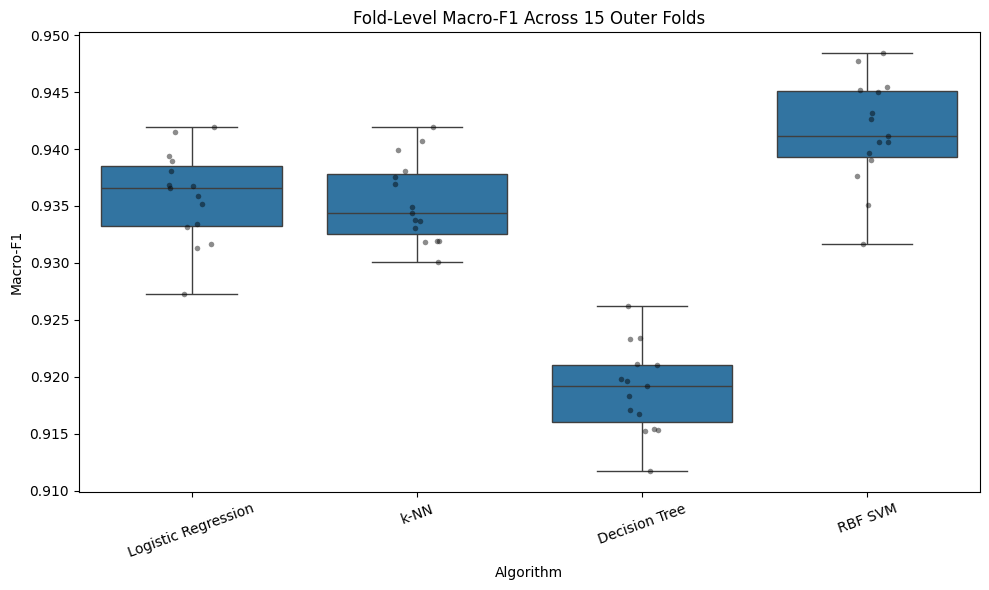

In [28]:
# ============================================================
# CELL 21 — FIGURE 1: MACRO-F1 DISTRIBUTIONS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=fold_results_df,
    x="algorithm",
    y="macro_f1"
)

sns.stripplot(
    data=fold_results_df,
    x="algorithm",
    y="macro_f1",
    color="black",
    alpha=0.45,
    size=4
)

plt.title(
    "Fold-Level Macro-F1 Across 15 Outer Folds"
)

plt.xlabel("Algorithm")
plt.ylabel("Macro-F1")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "figure1_macro_f1_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

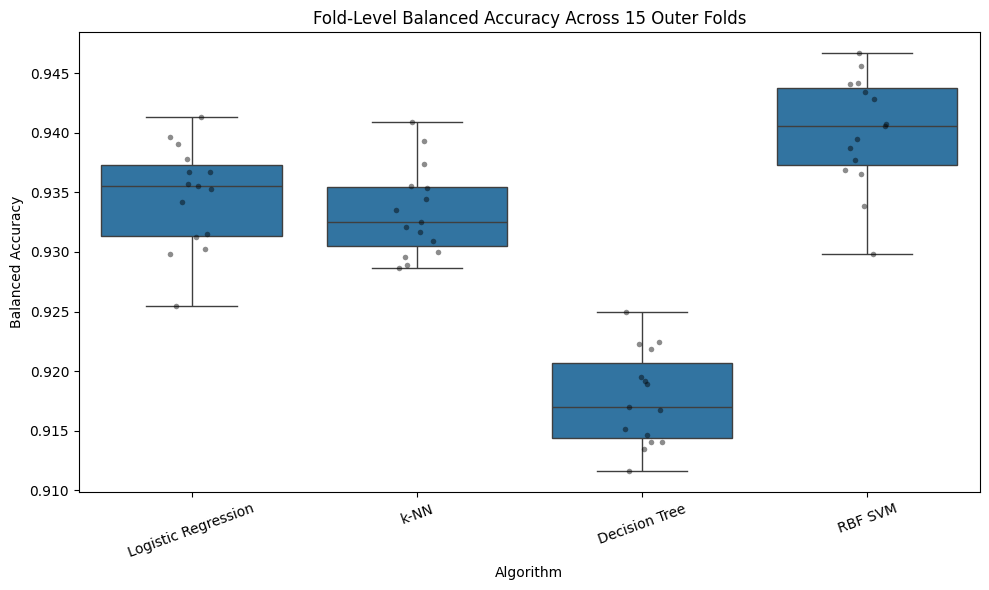

In [29]:
# ============================================================
# CELL 22 — BALANCED ACCURACY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=fold_results_df,
    x="algorithm",
    y="balanced_accuracy"
)

sns.stripplot(
    data=fold_results_df,
    x="algorithm",
    y="balanced_accuracy",
    color="black",
    alpha=0.45,
    size=4
)

plt.title(
    "Fold-Level Balanced Accuracy Across 15 Outer Folds"
)

plt.xlabel("Algorithm")
plt.ylabel("Balanced Accuracy")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "figure1_balanced_accuracy_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

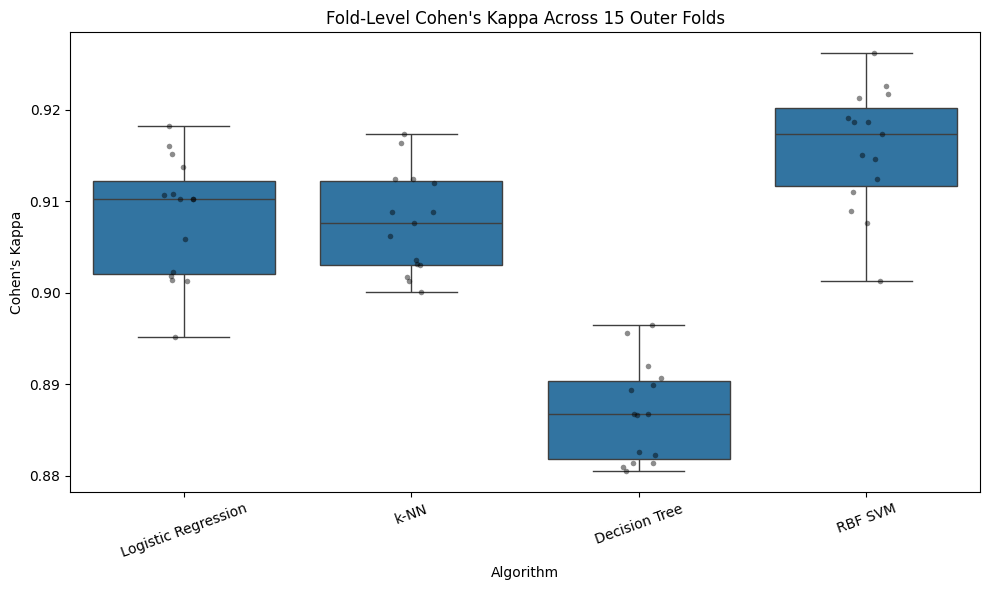

In [30]:
# ============================================================
# CELL 23 — COHEN'S KAPPA DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=fold_results_df,
    x="algorithm",
    y="cohen_kappa"
)

sns.stripplot(
    data=fold_results_df,
    x="algorithm",
    y="cohen_kappa",
    color="black",
    alpha=0.45,
    size=4
)

plt.title(
    "Fold-Level Cohen's Kappa Across 15 Outer Folds"
)

plt.xlabel("Algorithm")
plt.ylabel("Cohen's Kappa")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "figure1_cohen_kappa_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

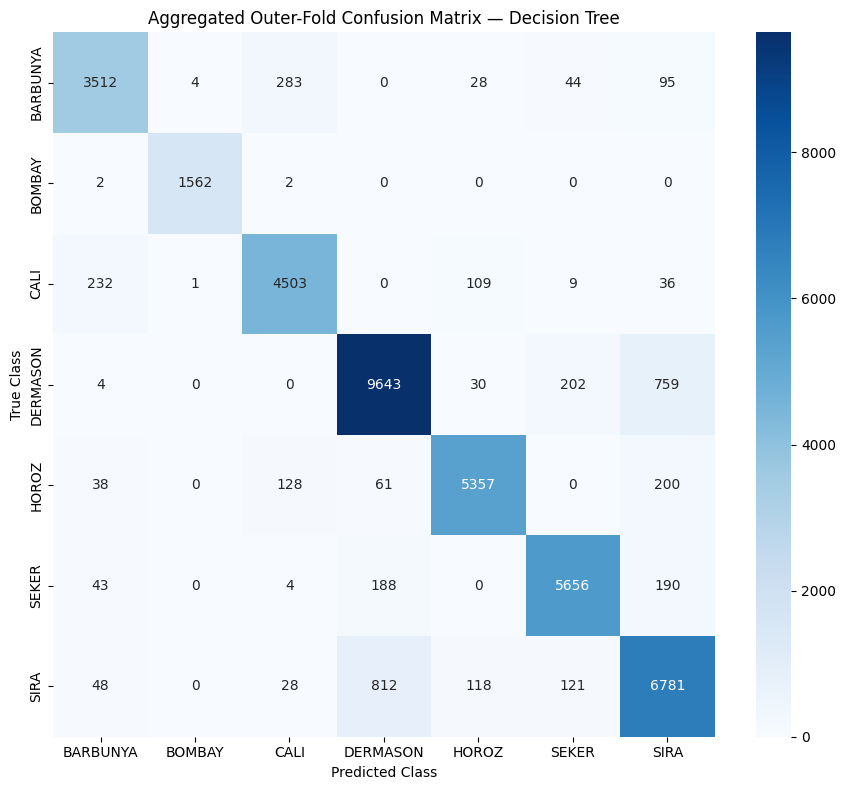

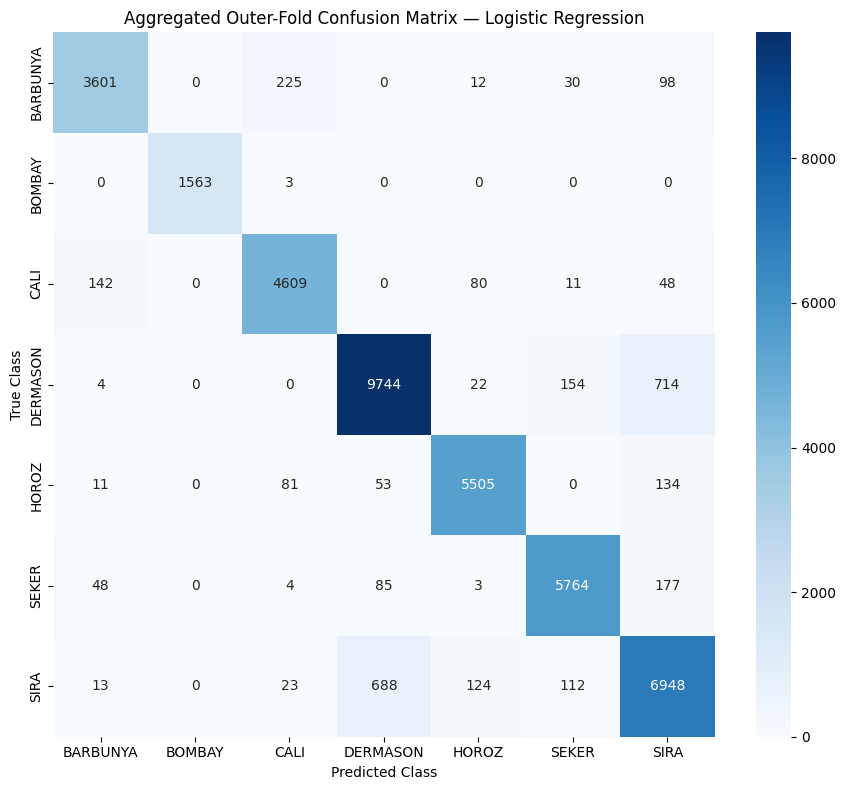

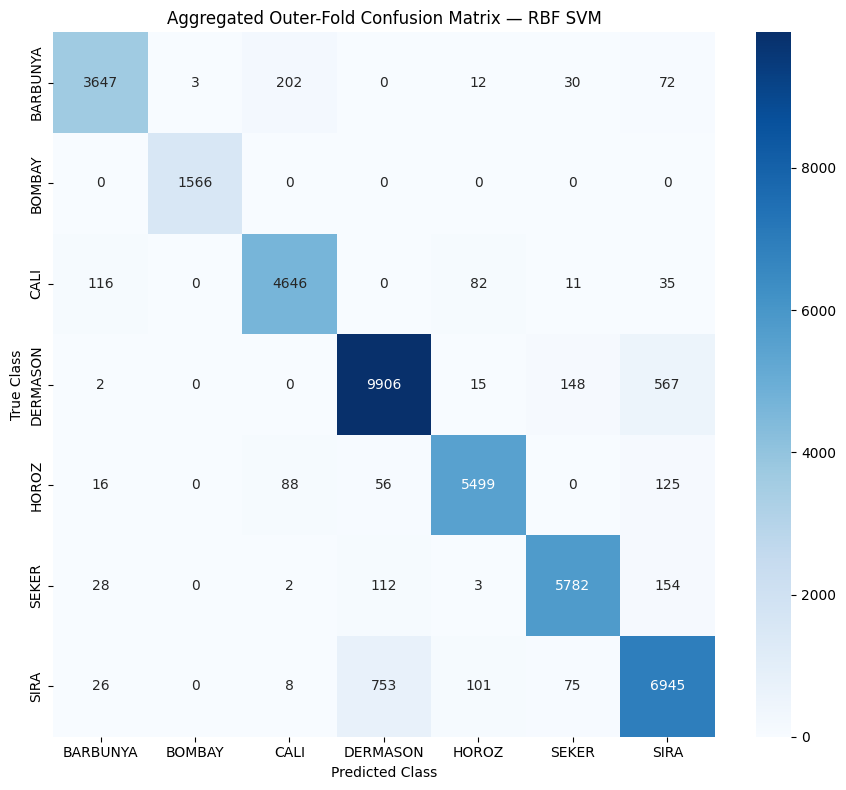

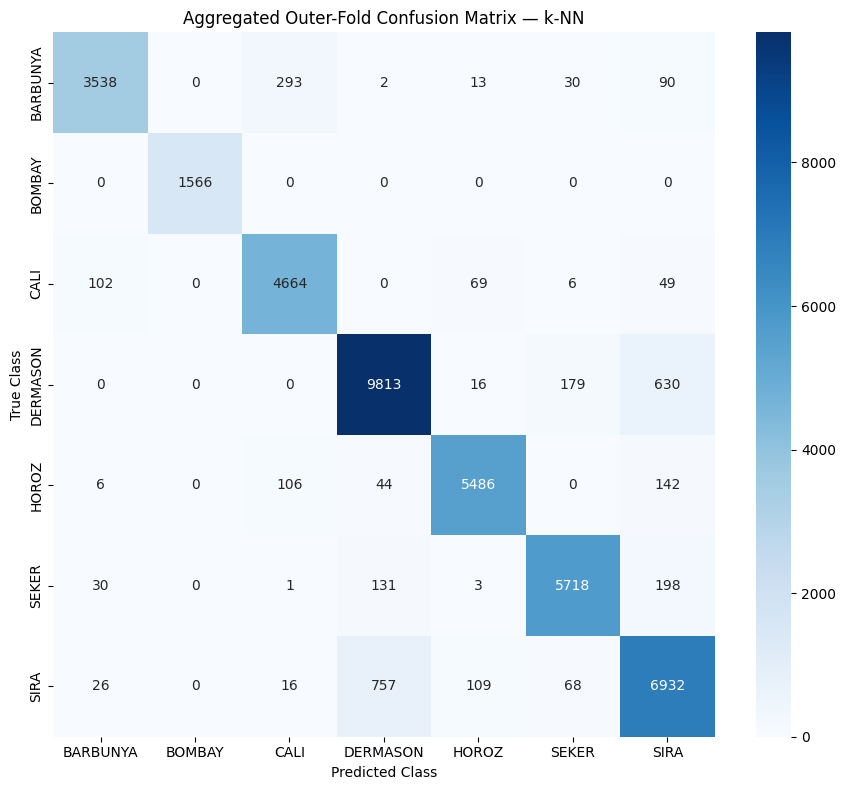

In [31]:
# ============================================================
# CELL 24 — FIGURE 2: CONFUSION MATRICES
# ============================================================

class_labels = sorted(
    y.unique()
)

for algorithm in algorithm_names:

    subset = confusion_results_df[
        confusion_results_df[
            "algorithm"
        ] == algorithm
    ]

    aggregated_cm = (
        subset
        .groupby(
            [
                "true_class",
                "predicted_class"
            ]
        )["count"]
        .sum()
        .unstack(
            fill_value=0
        )
    )

    aggregated_cm = (
        aggregated_cm
        .reindex(
            index=class_labels,
            columns=class_labels,
            fill_value=0
        )
    )

    plt.figure(
        figsize=(9, 8)
    )

    sns.heatmap(
        aggregated_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(
        "Aggregated Outer-Fold Confusion Matrix — "
        + algorithm
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )

    plt.tight_layout()

    safe_name = (
        algorithm
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        FIGURES_DIR /
        f"figure2_confusion_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [32]:
# ============================================================
# CELL 25 — MOST CONFUSED VARIETY PAIR
# ============================================================

best_confusion = (
    confusion_results_df[
        confusion_results_df[
            "algorithm"
        ] == best_algorithm
    ]
    .groupby(
        [
            "true_class",
            "predicted_class"
        ]
    )["count"]
    .sum()
    .unstack(
        fill_value=0
    )
)

best_confusion = (
    best_confusion
    .reindex(
        index=class_labels,
        columns=class_labels,
        fill_value=0
    )
)

# Remove diagonal
off_diagonal = (
    best_confusion.copy()
)

for label in class_labels:

    off_diagonal.loc[
        label,
        label
    ] = 0

confusion_pairs = (
    off_diagonal
    .stack()
    .sort_values(
        ascending=False
    )
)

print(
    "Best model:",
    best_algorithm
)

print(
    "\nTwo strongest confusion directions:"
)

display(
    confusion_pairs.head(2)
)

# Save
confusion_pairs.head(10).reset_index(
    name="Confusion Count"
).to_csv(
    RESULTS_DIR /
    "most_confused_classes.csv",
    index=False
)

Best model: RBF SVM

Two strongest confusion directions:


,,0
true_class,predicted_class,
SIRA,DERMASON,753
DERMASON,SIRA,567


In [ ]:
# ============================================================
# CELL 26 — FULL REDUCED-FEATURE ABLATION
# ============================================================

ablation_results = []

ablation_start = time.perf_counter()

print("=" * 80)
print("STARTING REDUCED-FEATURE ABLATION")
print("=" * 80)

for split in outer_splits:

    repeat_number = split["repeat"]

    repeat_seed = split["seed"]

    fold_number = split["fold"]

    train_indices = split[
        "train_indices"
    ]

    test_indices = split[
        "test_indices"
    ]

    X_train = X_reduced.iloc[
        train_indices
    ]

    X_test = X_reduced.iloc[
        test_indices
    ]

    y_train = y.iloc[
        train_indices
    ]

    y_test = y.iloc[
        test_indices
    ]

    print(
        f"\nRepeat {repeat_number} | "
        f"Fold {fold_number}"
    )

    for algorithm_name, configuration in (
        create_models(
            seed=repeat_seed
        ).items()
    ):

        inner_cv = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=(
                repeat_seed * 100
                + fold_number
            )
        )

        search = GridSearchCV(

            estimator=(
                configuration["estimator"]
            ),

            param_grid=(
                configuration["param_grid"]
            ),

            scoring=PRIMARY_SCORING,

            cv=inner_cv,

            n_jobs=-1,

            refit=True
        )

        fit_start = time.perf_counter()

        search.fit(
            X_train,
            y_train
        )

        fit_time = (
            time.perf_counter()
            - fit_start
        )

        prediction_start = (
            time.perf_counter()
        )

        y_pred = (
            search.best_estimator_
            .predict(X_test)
        )

        prediction_time = (
            time.perf_counter()
            - prediction_start
        )

        ablation_results.append({

            "repeat":
                repeat_number,

            "repeat_seed":
                repeat_seed,

            "fold":
                fold_number,

            "algorithm":
                algorithm_name,

            "macro_f1":
                f1_score(
                    y_test,
                    y_pred,
                    average="macro"
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_test,
                    y_pred
                ),

            "cohen_kappa":
                cohen_kappa_score(
                    y_test,
                    y_pred
                ),

            "fit_time_seconds":
                fit_time,

            "prediction_time_seconds":
                prediction_time,

            "best_params":
                str(
                    search.best_params_
                )
        })

        print(
            f"  {algorithm_name}: "
            f"{ablation_results[-1]['macro_f1']:.4f}"
        )

ablation_fold_df = pd.DataFrame(
    ablation_results
)

ablation_fold_df.to_csv(
    RESULTS_DIR /
    "ablation_fold_results.csv",
    index=False
)

ablation_runtime = (
    time.perf_counter()
    - ablation_start
)

print("\n")
print("=" * 80)
print("ABLATION COMPLETE")
print("=" * 80)

print(
    f"\nAblation runtime: "
    f"{ablation_runtime / 60:.2f} minutes"
)

print(
    "Ablation rows:",
    len(ablation_fold_df)
)

assert len(
    ablation_fold_df
) == 60

STARTING REDUCED-FEATURE ABLATION

Repeat 1 | Fold 1
  Logistic Regression: 0.9287
  k-NN: 0.9285
  Decision Tree: 0.9176
  RBF SVM: 0.9344

Repeat 1 | Fold 2
  Logistic Regression: 0.9404
  k-NN: 0.9375
  Decision Tree: 0.9187
  RBF SVM: 0.9454

Repeat 1 | Fold 3
  Logistic Regression: 0.9359
  k-NN: 0.9393
  Decision Tree: 0.9113
  RBF SVM: 0.9462

Repeat 1 | Fold 4
  Logistic Regression: 0.9393
  k-NN: 0.9399
  Decision Tree: 0.9223
  RBF SVM: 0.9452

Repeat 1 | Fold 5
  Logistic Regression: 0.9347
  k-NN: 0.9335
  Decision Tree: 0.9258
  RBF SVM: 0.9396

Repeat 2 | Fold 1
  Logistic Regression: 0.9324
  k-NN: 0.9292
  Decision Tree: 0.9194
  RBF SVM: 0.9367

Repeat 2 | Fold 2
  Logistic Regression: 0.9380
  k-NN: 0.9333
  Decision Tree: 0.9231
  RBF SVM: 0.9415

Repeat 2 | Fold 3
  Logistic Regression: 0.9418


In [ ]:
# ============================================================
# CELL 27 — ABLATION SUMMARY
# ============================================================

ablation_summary = (
    ablation_fold_df
    .groupby("algorithm")
    .agg(

        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),

        macro_f1_sd=(
            "macro_f1",
            "std"
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_sd=(
            "balanced_accuracy",
            "std"
        ),

        cohen_kappa_mean=(
            "cohen_kappa",
            "mean"
        ),

        cohen_kappa_sd=(
            "cohen_kappa",
            "std"
        )
    )
    .reset_index()
)

display(
    ablation_summary.round(5)
)

ablation_summary.to_csv(
    RESULTS_DIR /
    "ablation_summary.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 28 — FULL VS REDUCED COMPARISON
# ============================================================

full_for_comparison = (
    summary_df[
        [
            "algorithm",
            "macro_f1_mean",
            "macro_f1_sd",
            "balanced_accuracy_mean",
            "balanced_accuracy_sd",
            "cohen_kappa_mean",
            "cohen_kappa_sd"
        ]
    ]
    .copy()
)

full_for_comparison[
    "feature_set"
] = "Full"

reduced_for_comparison = (
    ablation_summary.copy()
)

reduced_for_comparison[
    "feature_set"
] = "Reduced"

full_vs_reduced = pd.concat(
    [
        full_for_comparison,
        reduced_for_comparison
    ],
    ignore_index=True
)

display(
    full_vs_reduced.round(5)
)

full_vs_reduced.to_csv(
    RESULTS_DIR /
    "full_vs_reduced_comparison.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 29 — ABLATION PERFORMANCE CHANGE
# ============================================================

full_indexed = (
    full_for_comparison
    .set_index("algorithm")
)

reduced_indexed = (
    reduced_for_comparison
    .set_index("algorithm")
)

ablation_change = pd.DataFrame({

    "Algorithm":
        full_indexed.index,

    "Full Macro-F1":
        full_indexed[
            "macro_f1_mean"
        ],

    "Reduced Macro-F1":
        reduced_indexed[
            "macro_f1_mean"
        ],

    "Macro-F1 Change":
        reduced_indexed[
            "macro_f1_mean"
        ]
        -
        full_indexed[
            "macro_f1_mean"
        ],

    "Full Balanced Accuracy":
        full_indexed[
            "balanced_accuracy_mean"
        ],

    "Reduced Balanced Accuracy":
        reduced_indexed[
            "balanced_accuracy_mean"
        ],

    "Balanced Accuracy Change":
        reduced_indexed[
            "balanced_accuracy_mean"
        ]
        -
        full_indexed[
            "balanced_accuracy_mean"
        ],

    "Full Cohen's Kappa":
        full_indexed[
            "cohen_kappa_mean"
        ],

    "Reduced Cohen's Kappa":
        reduced_indexed[
            "cohen_kappa_mean"
        ],

    "Kappa Change":
        reduced_indexed[
            "cohen_kappa_mean"
        ]
        -
        full_indexed[
            "cohen_kappa_mean"
        ]
})

display(
    ablation_change.round(5)
)

ablation_change.to_csv(
    RESULTS_DIR /
    "ablation_performance_change.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 30 — FIGURE 3: ABLATION
# ============================================================

ablation_plot_data = []

for _, row in (
    ablation_change.iterrows()
):

    ablation_plot_data.append({

        "Algorithm":
            row["Algorithm"],

        "Feature Set":
            "Full",

        "Macro-F1":
            row["Full Macro-F1"]
    })

    ablation_plot_data.append({

        "Algorithm":
            row["Algorithm"],

        "Feature Set":
            "Reduced",

        "Macro-F1":
            row["Reduced Macro-F1"]
    })

ablation_plot_df = pd.DataFrame(
    ablation_plot_data
)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=ablation_plot_df,
    x="Algorithm",
    y="Macro-F1",
    hue="Feature Set"
)

plt.title(
    "Full vs Reduced Feature Macro-F1"
)

plt.xlabel("Algorithm")
plt.ylabel("Macro-F1")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "figure3_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 31 — TIMING RESULTS
# ============================================================

timing_table = summary_df[
    [
        "algorithm",
        "fit_time_mean",
        "fit_time_sd",
        "prediction_time_mean",
        "prediction_time_sd"
    ]
].copy()

timing_table = (
    timing_table
    .sort_values(
        "fit_time_mean"
    )
)

display(
    timing_table.round(4)
)

timing_table.to_csv(
    RESULTS_DIR /
    "timing_comparison.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 32 — TRAINING TIME FIGURE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=timing_table,
    x="algorithm",
    y="fit_time_mean"
)

plt.title(
    "Mean Outer-Fold Training and Tuning Time"
)

plt.xlabel("Algorithm")
plt.ylabel("Time (seconds)")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 33 — SELECTED HYPERPARAMETERS
# ============================================================

selected_parameters = (
    fold_results_df[
        [
            "algorithm",
            "best_params"
        ]
    ]
    .value_counts()
    .reset_index(
        name="Selection Count"
    )
)

display(
    selected_parameters
)

selected_parameters.to_csv(
    RESULTS_DIR /
    "selected_hyperparameters.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 34 — TABLE 3: ALGORITHMS AND TUNING
# ============================================================

table_3 = pd.DataFrame({

    "Algorithm": [
        "Logistic Regression",
        "k-NN",
        "Decision Tree",
        "RBF SVM"
    ],

    "Family": [
        "Linear / probabilistic",
        "Instance-based",
        "Tree-based",
        "Kernel"
    ],

    "Search": [
        "GridSearchCV",
        "GridSearchCV",
        "GridSearchCV",
        "GridSearchCV"
    ],

    "Search Space": [
        "C ∈ {0.1, 1, 10}",
        "n_neighbors ∈ {5, 11, 21}",
        "max_depth ∈ {10, 20, None}",
        "C ∈ {1, 10, 100}; gamma='scale'"
    ],

    "Configurations": [
        3,
        3,
        3,
        3
    ],

    "Inner CV": [
        "2-fold",
        "2-fold",
        "2-fold",
        "2-fold"
    ],

    "Selection Metric": [
        "Macro-F1",
        "Macro-F1",
        "Macro-F1",
        "Macro-F1"
    ]
})

display(
    table_3
)

table_3.to_csv(
    RESULTS_DIR /
    "table_3_algorithms_and_tuning.csv",
    index=False
)

In [ ]:
# ============================================================
# CELL 35 — ENVIRONMENT / REPRODUCIBILITY
# ============================================================

import sklearn
import scipy
import statsmodels

environment = {

    "Python":
        sys.version,

    "Platform":
        platform.platform(),

    "NumPy":
        np.__version__,

    "Pandas":
        pd.__version__,

    "Scikit-learn":
        sklearn.__version__,

    "SciPy":
        scipy.__version__,

    "Statsmodels":
        statsmodels.__version__,

    "Global seed":
        GLOBAL_SEED,

    "Repeat seeds":
        REPEAT_SEEDS,

    "Outer folds":
        OUTER_FOLDS,

    "Repeats":
        N_REPEATS,

    "Inner folds":
        INNER_FOLDS,

    "Primary metric":
        PRIMARY_SCORING
}

environment_df = pd.DataFrame(
    list(environment.items()),
    columns=[
        "Setting",
        "Value"
    ]
)

display(
    environment_df
)

with open(
    RESULTS_DIR /
    "environment.json",
    "w"
) as file:

    json.dump(
        environment,
        file,
        indent=4,
        default=str
    )

In [ ]:
# ============================================================
# CELL 36 — REQUIREMENTS.TXT
# ============================================================

requirements = f"""
numpy=={np.__version__}
pandas=={pd.__version__}
scikit-learn=={sklearn.__version__}
scipy=={scipy.__version__}
statsmodels=={statsmodels.__version__}
seaborn=={sns.__version__}
ucimlrepo
openpyxl
""".strip()

with open(
    "requirements.txt",
    "w"
) as file:

    file.write(
        requirements
    )

print(
    requirements
)

In [ ]:
# ============================================================
# CELL 37 — README
# ============================================================

readme_text = f"""
# Robust Multi-Class Benchmarking on Dry Bean Morphology

## Dataset

UCI Dry Bean Dataset.

Dataset ID: 602

DOI: 10.24432/C50S4B

Observed dataset:
- Rows: {X.shape[0]}
- Features: {X.shape[1]}
- Classes: {y.nunique()}

## Algorithms

Four classifiers from four model families were evaluated:

1. Logistic Regression
2. k-NN
3. Decision Tree
4. RBF SVM

## Validation

Repeated nested stratified cross-validation:

- Outer CV: {OUTER_FOLDS}-fold
- Repetitions: {N_REPEATS}
- Outer folds per algorithm: {OUTER_FOLDS * N_REPEATS}
- Inner CV: {INNER_FOLDS}-fold
- Primary tuning metric: {PRIMARY_SCORING}

Repetition seeds:

{REPEAT_SEEDS}

## Hyperparameter tuning

Each algorithm uses three candidate configurations.

Logistic Regression:
- C = 0.1, 1, 10
- solver = lbfgs

k-NN:
- n_neighbors = 5, 11, 21

Decision Tree:
- max_depth = 10, 20, None

RBF SVM:
- C = 1, 10, 100
- gamma = scale

## Evaluation metrics

- Macro-F1
- Balanced Accuracy
- Cohen's Kappa
- Per-class Recall
- Training/Tuning Time
- Prediction Time

## Statistical analysis

- Friedman test
- Kendall's W
- Pairwise Wilcoxon signed-rank tests
- Holm multiple-comparison correction
- Wilcoxon effect size r

## Ablation

The reduced feature experiment removes:

{chr(10).join("- " + feature for feature in REDUCED_DROP)}

The same 15 outer folds and nested tuning procedure are used.

## Reproducibility

All experiment outputs are generated programmatically.

The `results/` directory contains raw fold-level data and statistical results.

The `figures/` directory contains the generated figures.

The notebook downloads the UCI dataset programmatically.

"""

with open(
    "README.md",
    "w"
) as file:

    file.write(
        readme_text.strip()
    )

print(
    readme_text
)

In [ ]:
# ============================================================
# CELL 38 — FINAL ASSIGNMENT COMPLIANCE CHECK
# ============================================================

checks = {

    "Dataset loaded":
        X.shape[0] > 0,

    "16 features":
        X.shape[1] == 16,

    "7 classes":
        y.nunique() == 7,

    "Missing values audited":
        True,

    "Duplicates audited":
        True,

    "4 algorithms":
        len(models) == 4,

    "At least 3 families":
        True,

    "5-fold outer CV":
        OUTER_FOLDS >= 5,

    "3 repetitions":
        N_REPEATS >= 3,

    "15 outer folds/model":
        all(
            fold_results_df
            .groupby("algorithm")
            .size()
            == 15
        ),

    "Inner tuning":
        INNER_FOLDS >= 2,

    "Macro-F1":
        "macro_f1"
        in fold_results_df.columns,

    "Balanced Accuracy":
        "balanced_accuracy"
        in fold_results_df.columns,

    "Cohen's Kappa":
        "cohen_kappa"
        in fold_results_df.columns,

    "Per-class recall":
        len(
            per_class_results_df
        ) > 0,

    "Timing":
        "fit_time_seconds"
        in fold_results_df.columns,

    "Confusion matrices":
        len(
            confusion_results_df
        ) > 0,

    "Friedman test":
        os.path.exists(
            RESULTS_DIR /
            "friedman_test.csv"
        ),

    "Post-hoc tests":
        os.path.exists(
            RESULTS_DIR /
            "pairwise_wilcoxon_holm.csv"
        ),

    "Effect size":
        os.path.exists(
            RESULTS_DIR /
            "friedman_test.csv"
        ),

    "Ablation":
        os.path.exists(
            RESULTS_DIR /
            "ablation_summary.csv"
        ),

    "Environment recorded":
        os.path.exists(
            RESULTS_DIR /
            "environment.json"
        ),

    "Main raw CSV":
        os.path.exists(
            RESULTS_DIR /
            "fold_results_full.csv"
        )
}

compliance_df = pd.DataFrame({

    "Requirement":
        list(checks.keys()),

    "Status": [
        "PASS" if value else "CHECK"
        for value in checks.values()
    ]
})

display(
    compliance_df
)

passed = sum(
    checks.values()
)

total = len(checks)

print(
    f"\n{passed}/{total} checks passed."
)

if passed != total:

    raise RuntimeError(
        "One or more compliance checks failed. "
        "Review the table above before submission."
    )

print(
    "\n✓ ALL AUTOMATED COMPLIANCE CHECKS PASSED."
)

In [ ]:
# ============================================================
# CELL 39 — PACKAGE EVERYTHING
# ============================================================

submission_folder = Path(
    "P5_Dry_Bean_Submission"
)

if submission_folder.exists():

    shutil.rmtree(
        submission_folder
    )

submission_folder.mkdir()

# ------------------------------------------------------------
# Copy results
# ------------------------------------------------------------

shutil.copytree(
    RESULTS_DIR,
    submission_folder / "results"
)

# ------------------------------------------------------------
# Copy figures
# ------------------------------------------------------------

shutil.copytree(
    FIGURES_DIR,
    submission_folder / "figures"
)

# ------------------------------------------------------------
# Copy documentation
# ------------------------------------------------------------

shutil.copy(
    "README.md",
    submission_folder / "README.md"
)

shutil.copy(
    "requirements.txt",
    submission_folder / "requirements.txt"
)

# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

zip_file = shutil.make_archive(
    "P5_Dry_Bean_Submission",
    "zip",
    submission_folder
)

print(
    "Submission package created:"
)

print(
    zip_file
)

print(
    "\nContents:"
)

for path in submission_folder.rglob("*"):

    if path.is_file():

        print(
            " -",
            path.relative_to(
                submission_folder
            )
        )

In [ ]:
# ============================================================
# CELL 40 — FINAL RESULTS SNAPSHOT
# ============================================================

print("=" * 80)
print("FINAL EXPERIMENT RESULTS")
print("=" * 80)

print(
    "\nMAIN RESULTS"
)

display(
    table_4
)

print(
    "\nFRIEDMAN TEST"
)

display(
    friedman_summary.round(5)
)

print(
    "\nPOST-HOC COMPARISONS"
)

display(
    pairwise_report.round(5)
)

print(
    "\nABLATION"
)

display(
    ablation_change.round(5)
)

print(
    "\nBEST MODEL BY MEAN MACRO-F1:"
)

print(
    best_algorithm
)

print(
    "\nSubmission ZIP:"
)

print(
    zip_file
)

print(
    "\n✓ NOTEBOOK COMPLETE."
)